In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from pathlib import Path
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import cross_val_score
import time

In [18]:
# Load datasets
normal = pd.read_csv("no-jammer.csv").dropna()
jammer = pd.read_csv("jammer.csv").dropna()


In [19]:
# Select features
anomalyInputs = [
   "SF", "CF", "TX", "BW", "CR", "SNR", "RSSI", "PktSeqNum", 
   "payloadSize", "numReceivedPerNode[nodeNumber-1]", "PDRPerNode", 
   "numReceivedPerNodePerWindow[nodeNumber]", "currentSeqNum", 
   "lastSeqNumAtWindowStart[nodeNumber]", "pdrPerNodePerWindow[nodeNumber]", 
   "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs1 = [
   "SF", "CF", "SNR", "RSSI", "PktSeqNum", "numReceivedPerNode[nodeNumber-1]", "PDRPerNode", 
   "numReceivedPerNodePerWindow[nodeNumber]", "currentSeqNum", 
   "lastSeqNumAtWindowStart[nodeNumber]", "pdrPerNodePerWindow[nodeNumber]", 
   "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs2 = [
   "SF", "CF", "SNR", "RSSI", "PktSeqNum", "currentSeqNum", "lastSeqNumAtWindowStart[nodeNumber]", "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs3 = [
   "SF", "CF", "SNR", "RSSI", "interArrivalTime_s", "interArrivalTimeMin" 
]

anomalyInputs4 = [
   "SF", "CF", "SNR", "RSSI", "interArrivalTime_s",  
]

In [20]:
#scaler = StandardScaler()
scaler = MinMaxScaler()

# Cleaning up column names
normal.columns = normal.columns.str.strip()
jammer.columns = jammer.columns.str.strip()

normal2 = scaler.fit_transform(normal[anomalyInputs4]) 
jammer2 = scaler.transform(jammer[anomalyInputs4])

print(f"Normal set length: {len(normal)}")
print(f"Jammer set length: {len(jammer)}")

Normal set length: 99381
Jammer set length: 98752


In [21]:
# Use 80% to train the "baseline" of your network
normalTrain, normalTest = train_test_split(normal2, test_size=0.2, random_state=42)

# Training models ONLY on clean normal data
contamination = 0.01 
#contamination = 'auto'

model = IsolationForest(contamination=contamination, random_state=42)
model.fit(normalTrain)

model2 = LocalOutlierFactor(contamination=contamination, novelty=True)
model2.fit(normalTrain)

,n_neighbors,20
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,contamination,0.01
,novelty,True
,n_jobs,None


Accuracy on Normal: 0.991
Accuracy: 0.918
Precision: 0.906
Recall: 0.838
F1 Score: 0.870
ROC-AUC: 0.978
Classification Report - IF
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     66229
           1       0.91      0.84      0.87     32523

    accuracy                           0.92     98752
   macro avg       0.91      0.90      0.91     98752
weighted avg       0.92      0.92      0.92     98752



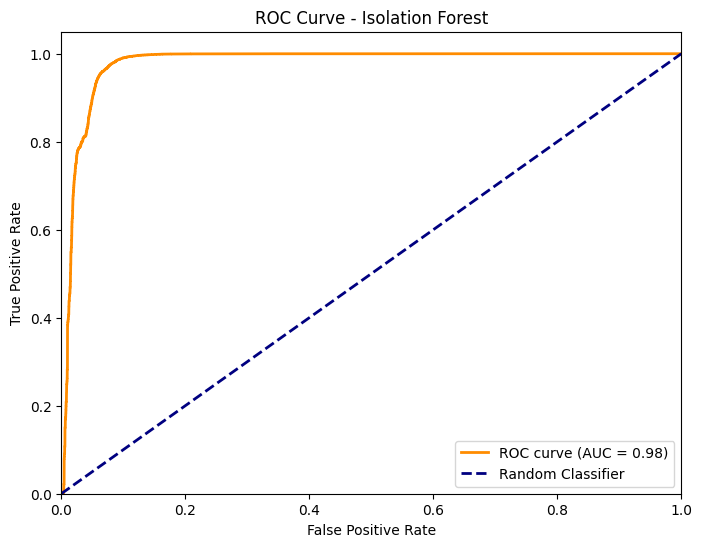

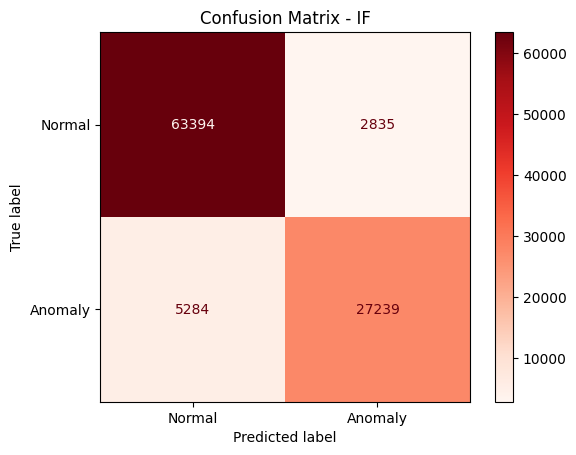

In [22]:
# Test on 20% normal set
predNormalTestIF = (model.predict(normalTest) == -1).astype(int)
yTrueNormalIF = np.zeros(len(normalTest))
accNormalIF = accuracy_score(yTrueNormalIF, predNormalTestIF)
print(f"Accuracy on Normal: {accNormalIF:.3f}")

# Test on jammer set
jammer['anomaly'] = model.predict(jammer2)
jammer['isAnomaly'] = (jammer['NodeID'] == 121).astype(int)
predictionJammerIF = (jammer['anomaly'] == -1).astype(int) 
yTrueJammerIF = jammer['isAnomaly']
accJammerIF = accuracy_score(yTrueJammerIF, predictionJammerIF)
print(f"Accuracy: {accJammerIF:.3f}")

precision_if = precision_score(yTrueJammerIF, predictionJammerIF)
print(f"Precision: {precision_if:.3f}")

recall_if = recall_score(yTrueJammerIF, predictionJammerIF)
print(f"Recall: {recall_if:.3f}")

f1_if = f1_score(yTrueJammerIF, predictionJammerIF)
print(f"F1 Score: {f1_if:.3f}")

auc_score = roc_auc_score(yTrueJammerIF, -model.score_samples(jammer2))
print(f"ROC-AUC: {auc_score:.3f}")

#silhouette_if = silhouette_score(jammer2, predictionJammerIF)
#print(f"Silhouette Score: {silhouette_if:.3f}")

fpr_if, tpr_if, _ = roc_curve(yTrueJammerIF, -model.score_samples(jammer2))
roc_auc_if = auc(fpr_if, tpr_if)

# Final evaluation metrics
print("Classification Report - IF")
print(classification_report(yTrueJammerIF, predictionJammerIF))

plt.figure(figsize=(8, 6))
plt.plot(fpr_if, tpr_if, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_if:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Isolation Forest')
plt.legend(loc="lower right")
plt.show()

cm = confusion_matrix(yTrueJammerIF, predictionJammerIF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix - IF')
plt.show()

Accuracy on Normal: 0.990
Accuracy: 0.918
ROC-AUC: 0.966
Precision: 0.884
Recall: 0.865
F1 Score: 0.874


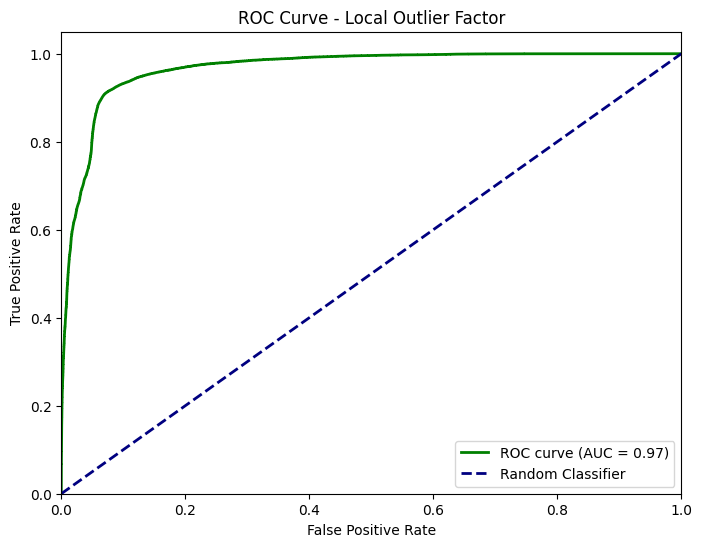

Classification Report - LOF
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     66229
           1       0.88      0.86      0.87     32523

    accuracy                           0.92     98752
   macro avg       0.91      0.90      0.91     98752
weighted avg       0.92      0.92      0.92     98752



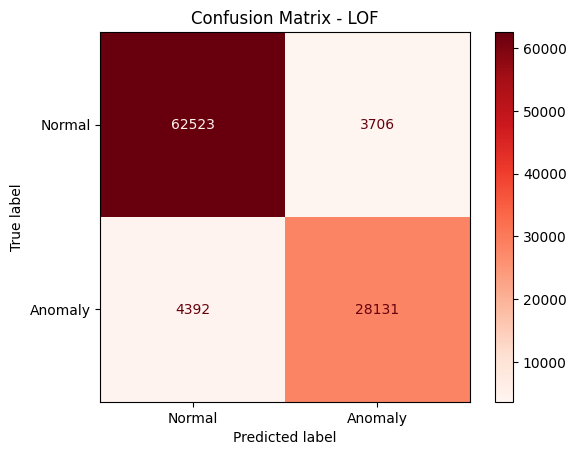

In [23]:
# Test on 20% normal set
predNormalTestLOF = (model2.predict(normalTest) == -1).astype(int)
yTrueNormalLOF = np.zeros(len(normalTest))
accNormalLOF = accuracy_score(yTrueNormalLOF, predNormalTestLOF)
print(f"Accuracy on Normal: {accNormalLOF:.3f}")

# Test on jammer set
jammer['anomaly'] = model2.predict(jammer2)
jammer['isAnomaly'] = (jammer['NodeID'] == 121).astype(int)
predictionJammerLOF = (jammer['anomaly'] == -1).astype(int) 
yTrueJammerLOF = jammer['isAnomaly']
accJammerLOF = accuracy_score(yTrueJammerLOF, predictionJammerLOF)
print(f"Accuracy: {accJammerLOF:.3f}")

auc_score = roc_auc_score(yTrueJammerLOF, -model2.score_samples(jammer2))
print(f"ROC-AUC: {auc_score:.3f}")

precision_lof = precision_score(yTrueJammerLOF, predictionJammerLOF)
print(f"Precision: {precision_lof:.3f}")

recall_lof = recall_score(yTrueJammerLOF, predictionJammerLOF)
print(f"Recall: {recall_lof:.3f}")

f1_lof = f1_score(yTrueJammerLOF, predictionJammerLOF)
print(f"F1 Score: {f1_lof:.3f}")

#silhouette_lof = silhouette_score(jammer2, predictionJammerIF)
#print(f"Silhouette Score: {silhouette_lof:.3f}")

fpr_lof, tpr_lof, _ = roc_curve(yTrueJammerLOF, -model2.score_samples(jammer2))
roc_auc_lof = auc(fpr_lof, tpr_lof)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lof, tpr_lof, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_lof:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Local Outlier Factor')
plt.legend(loc="lower right")
plt.show()

# Final evaluation metrics
print("Classification Report - LOF")
print(classification_report(yTrueJammerLOF, predictionJammerLOF))

cm = confusion_matrix(yTrueJammerLOF, predictionJammerLOF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix - LOF')
plt.show()

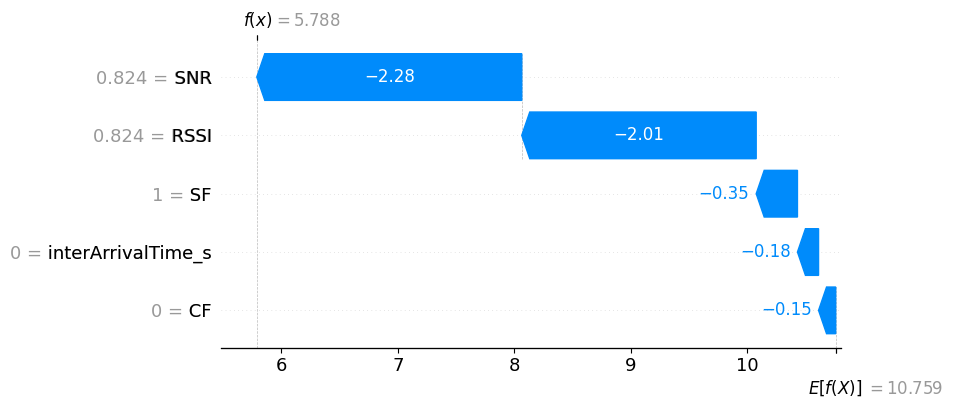

In [24]:
# Show only the SHAP waterfall for one flagged packet
flagged_indices = np.where(predictionJammerIF == 1)[0]

if len(flagged_indices) > 0:
    idx = flagged_indices[0]
    packet_scaled = pd.DataFrame([jammer2[idx]], columns=anomalyInputs4)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(packet_scaled)[0]

    explanation = shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=packet_scaled.iloc[0],
        feature_names=packet_scaled.columns
    )

    shap.plots.waterfall(explanation)